In [3]:
from google.colab import files
files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d nirmalsankalana/plantdoc-dataset
!unzip plantdoc-dataset.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 10, in <module>
    sys.exit(main())
             ^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/cli.py", line 68, in main
    out = args.func(**command_args)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 1741, in dataset_download_cli
    with self.build_kaggle_client() as kaggle:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 688, in build_kaggle_client
    username=self.config_values['username'],
             ~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
KeyError: 'username'
unzip:  cannot find or open plantdoc-dataset.zip, plantdoc-dataset.zip.zip or plantdoc-dataset.zip.ZIP.


In [2]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth

  Preparing metadata (setup.py) ... done


In [3]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

import os
import cv2
import numpy as np
from PIL import Image
import tqdm

In [4]:
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry["vit_b"](checkpoint="sam_vit_b_01ec64.pth")
sam.to("cpu")
predictor = SamPredictor(sam)

print("SAM on CPU")


SAM on CPU


## Segmentation by cropping

In [5]:
def segment_leaf_fast(image_rgb):

    predictor.set_image(image_rgb)

    h, w, _ = image_rgb.shape

    input_point = np.array([[w//2, h//2]])
    input_label = np.array([1])

    masks, scores, _ = predictor.predict(
        point_coords=input_point,
        point_labels=input_label,
        multimask_output=False
    )

    mask = masks[0]

    coords = np.column_stack(np.where(mask))

    if len(coords) == 0:
        return image_rgb

    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    return image_rgb[y_min:y_max, x_min:x_max]

Selected: train/grape_leaf/train_grape leaf_33.jpg


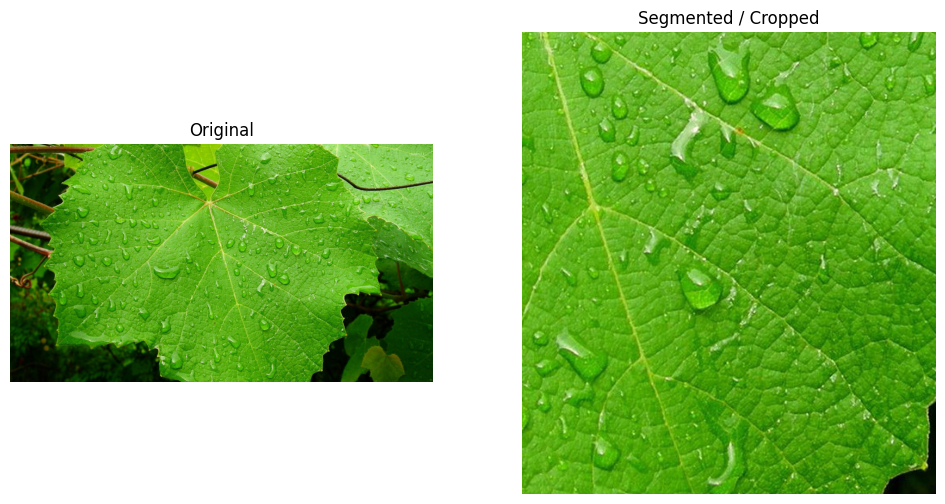

In [12]:
import random
import os
import cv2
import matplotlib.pyplot as plt

source_root = "train"

class_name = random.choice(os.listdir(source_root))
class_path = os.path.join(source_root, class_name)

img_name = random.choice(os.listdir(class_path))
img_path = os.path.join(class_path, img_name)

print("Selected:", img_path)

image = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

cropped = segment_leaf_fast(image_rgb)
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(image_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cropped)
plt.title("Segmented / Cropped")
plt.axis("off")

plt.show()

In [ ]:
selected_classes = [
    "Tomato_leaf_mosaic_virus",
    "Tomato_mold_leaf",
    "Tomato_leaf_bacterial_spot",
    "Tomato_leaf",
    "Tomato_Early_blight_leaf",
    "Bell_pepper_leaf",
    "Bell_pepper_leaf_spot",
    "Apple_Scab_Leaf",
    "Apple_leaf",
    "Apple_rust_leaf",
    "Corn_leaf_blight",
    "Corn_Gray_leaf_spot",
    "Corn_rust_leaf",
    "Potato_leaf_early_blight",
    "Potato_leaf_late_blight"
]

In [20]:
source_root = "train"
segmented_root = "PlantDoc_segmented_5"

os.makedirs(segmented_root, exist_ok=True)

for class_name in selected_classes:

    class_path = os.path.join(source_root, class_name)

    if not os.path.exists(class_path):
        print(f"{class_name} not found, skipping")
        continue

    save_class_path = os.path.join(segmented_root, class_name)
    os.makedirs(save_class_path, exist_ok=True)

    print(f"Processing {class_name}")

    for img_name in tqdm.tqdm(os.listdir(class_path)):

        img_path = os.path.join(class_path, img_name)
        image = cv2.imread(img_path)

        if image is None:
            continue

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        cropped = segment_leaf_fast(image_rgb)

        save_path = os.path.join(save_class_path, img_name)
        cv2.imwrite(save_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))


Processing Tomato_leaf_mosaic_virus


100%|██████████| 44/44 [15:19<00:00, 20.90s/it]


In [26]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Training on:", device)

Training on: cuda


In [42]:
train_transform = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomResizedCrop(300, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(35),
    transforms.ColorJitter(0.6, 0.6, 0.6, 0.2),
    transforms.RandomGrayscale(p=0.15),
    transforms.GaussianBlur(3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((300,300)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])


In [43]:
segmented_root = "PlantDoc_segmented_5"

full_dataset = datasets.ImageFolder(segmented_root, transform=train_transform)

indices = list(range(len(full_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_subset = Subset(full_dataset, train_idx)

val_dataset = datasets.ImageFolder(segmented_root, transform=val_transform)
val_subset = Subset(val_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=16, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", num_classes)

Classes: 5


In [44]:
model = models.efficientnet_b3(pretrained=True)

for param in model.features.parameters():
    param.requires_grad = False

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 105MB/s]


In [45]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10
)

In [46]:
def train_model(model, train_loader, val_loader, epochs):

    best_acc = 0

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs,1)

                total += labels.size(0)
                correct += (preds==labels).sum().item()

        val_acc = correct / total

        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_b3_model.pth")

        print(f"Epoch {epoch+1}: Loss={running_loss/len(train_loader):.4f} | Val Acc={val_acc:.4f}")

        scheduler.step()

    print("Best Validation Accuracy:", best_acc)

In [32]:
from sklearn.model_selection import train_test_split

full_dataset = datasets.ImageFolder(segmented_root, transform=train_transform)

indices = list(range(len(full_dataset)))
train_idx, val_idx = train_test_split(indices, test_size=0.2, random_state=42)

train_subset = torch.utils.data.Subset(full_dataset, train_idx)
val_subset = torch.utils.data.Subset(full_dataset, val_idx)

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)

In [33]:
def train_with_val(model, train_loader, val_loader, epochs=5):

    for epoch in range(epochs):

        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                _, preds = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (preds == labels).sum().item()

        val_acc = correct / total

        print(f"Epoch {epoch+1}: Loss = {running_loss/len(train_loader):.4f} | Val Acc = {val_acc:.4f}")

In [34]:
train_with_val(model, train_loader, val_loader, epochs=7)

Epoch 1: Loss = 1.1908 | Val Acc = 0.3944
Epoch 2: Loss = 1.1590 | Val Acc = 0.4789
Epoch 3: Loss = 1.1058 | Val Acc = 0.4225
Epoch 4: Loss = 1.1238 | Val Acc = 0.4648
Epoch 5: Loss = 1.0590 | Val Acc = 0.4930
Epoch 6: Loss = 1.0286 | Val Acc = 0.5211
Epoch 7: Loss = 0.9358 | Val Acc = 0.4789


In [39]:
for param in model.parameters():
    param.requires_grad = True

In [40]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=3,
    gamma=0.3
)

In [ ]:
train_model(model, train_loader, val_loader, epochs=12)